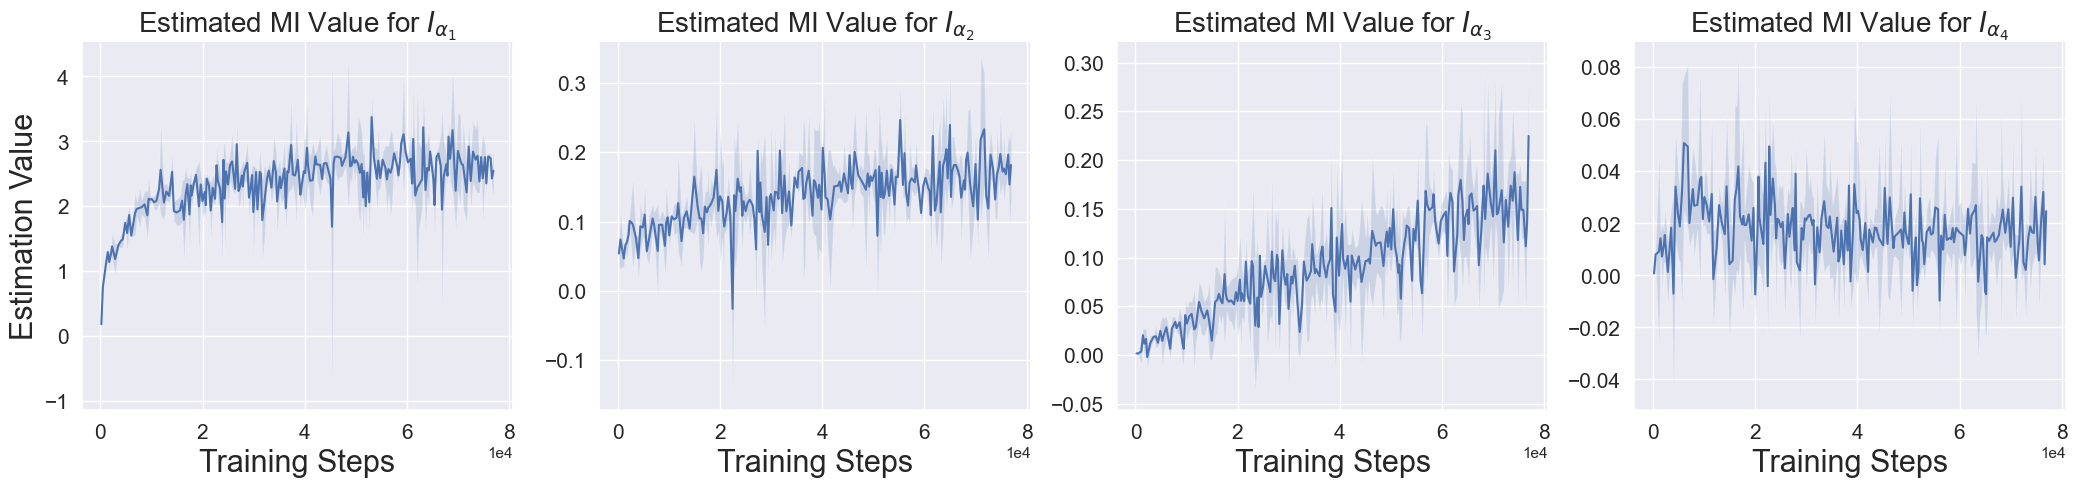

In [28]:
# Robodesk
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
color_list = sns.color_palette()
def plot_csv_files(ax, directory_path, title, interval=5, set_title=True, set_xlabel=True, set_ylabel=True):
    files = os.listdir(directory_path)
    fig_width = 6.4
    fig_height = 4.8
    scale = 1.3
    method_data = []
    all_data = []
    for file in files:
        if  file.endswith('.csv'):
            file_path = os.path.join(directory_path, file)
            df = pd.read_csv(file_path)
            df = df.drop(columns="Wall time")
            method_data.append(df)
    # print(len(method_data))
    if method_data:
            method_df = pd.concat(method_data)
            method_df = method_df.iloc[::interval]
            method_df_mean = method_df.groupby("Step").mean().reset_index()
            # print(method_df_mean.head(5))
            method_df_std = method_df.groupby("Step").std().reset_index()
            all_data.append(( 'IFactor', method_df_mean, method_df_std))
    # print(method_df_mean.head(10))
    ax.plot(method_df_mean["Step"], -method_df_mean['Value'])
    ax.fill_between(method_df_mean["Step"],-method_df_mean['Value'] - method_df_std['Value'], -method_df_mean['Value'] + method_df_std['Value'], alpha=0.2)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    if set_title:
        ax.set_title(title, fontsize=20)
    if set_xlabel:
        ax.set_xlabel('Training Steps', fontsize=22)
    if set_ylabel:
        ax.set_ylabel('Estimation Value', fontsize=22)
    
title_1 = r'Estimated MI Value for $I_{\alpha_1}$'
title_2 = r'Estimated MI Value for $I_{\alpha_2}$'
title_3 = r'Estimated MI Value for $I_{\alpha_3}$'
title_4 = r'Estimated MI Value for $I_{\alpha_4}$'
title_reward = r'$I_{\alpha_1} - I_{\alpha_2}$'
title_action = r'$I_{\alpha_3} - I_{\alpha_4}$'

fig,axes = plt.subplots(1,4, figsize=(25.6, 4.8),)
mine_action = 'anonymized_path'
mine_reward = 'anonymized_path'
mine1 = 'anonymized_path'
mine2 = 'anonymized_path'
mine3 = 'anonymized_path'
mine4 = 'anonymized_path'
plot_csv_files(axes[0], mine1, title_1, interval=5, set_title=True, set_xlabel=True, set_ylabel=True)
plot_csv_files(axes[1], mine2, title_2, interval=5, set_title=True, set_xlabel=True, set_ylabel=False)
plot_csv_files(axes[2], mine3, title_3, interval=5, set_title=True, set_xlabel=True, set_ylabel=False)
plot_csv_files(axes[3], mine4, title_4, interval=5, set_title=True, set_xlabel=True, set_ylabel=False)
               
plt.savefig('anonymized_path/mine.pdf', bbox_inches='tight')


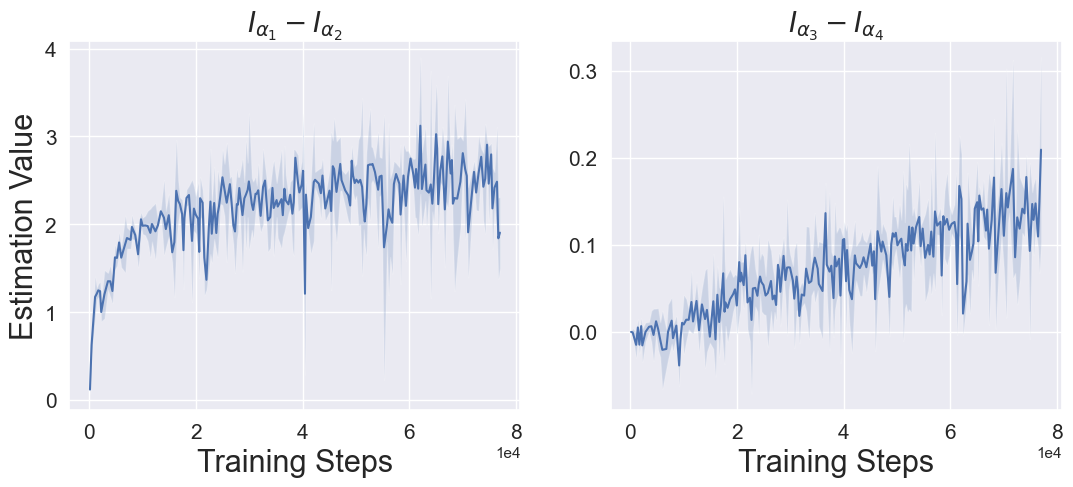

In [32]:
fig,axes = plt.subplots(1,2, figsize=(12.8, 4.8),)
plot_csv_files(axes[0], mine_reward, title_reward, interval=5, set_title=True, set_xlabel=True, set_ylabel=True)
plot_csv_files(axes[1], mine_action, title_action, interval=5, set_title=True, set_xlabel=True, set_ylabel=False)
plt.savefig('anonymized_path/mine_difference.pdf', bbox_inches='tight')
